# Background leverage and its 2.5% tails — IN, PR, RT

Same decomposition as `jterm_sd_heatmap_v2_range_sorted.ipynb`, three differences:

1. **all three proteins** — IN, PR and RT, each with its own alignment, redux dictionary and J.
2. **the top-20 ddE DRM pairs per protein**, read from `ms0_5/{protein}/data/top_20_DRM.txt`
   (RT's file carries both drug classes, 40 pairs). Top and bottom leverage are both taken from
   that one list, so the two tails describe the same set of pairs.
3. **one figure per protein**: the pooled distribution of sd of c(q) with both 2.5% tails shaded,
   then each tail on its own with its ten most extreme cells labelled by double mutation and q.
   No heat map, no per-pair ranked bars.

sd of c(q) is exactly 0 wherever the alignment never varies at q — that term is then the same
constant in every sequence. Those cells are counted and set aside rather than pooled: they are
not low leverage, they are no variation, and a log axis cannot show them.

In [1]:
import sys
import csv
import importlib
from pathlib import Path

import numpy as np
import pandas as pd

cwd = Path.cwd().resolve()
repo_root = next((c for c in [cwd, *cwd.parents] if (c / "utilities" / "functions.py").exists()), None)
if repo_root is None:
    raise FileNotFoundError("Could not find the repository root containing utilities/functions.py")
sys.path.append(str(repo_root))

import utilities.functions as functions

importlib.reload(functions)

data_root = repo_root / "ms0_5"


def build_J_matrix(j_file, min_position, max_position):
    """Dense coupling tensor, shape (L, L, 4, 5), indexed [p1, p2, aa_at_p1, aa_at_p2]."""
    J = np.load(j_file).astype(np.float32)
    L = max_position - min_position + 1
    Jm = np.zeros((L, L, 4, 5), dtype=np.float32)
    iu0, iu1 = np.triu_indices(L, 1)
    blocks = J.reshape(-1, 4, 4)
    assert blocks.shape[0] == iu0.size, "J.npy row count does not match the position range"
    Jm[iu0, iu1, :, :4] = blocks
    Jm[iu1, iu0, :, :4] = blocks.transpose(0, 2, 1)
    return Jm


CFG = {
    'IN': dict(seq='IN/data/in.reduce4.seq', redux='IN/data/in.reduce4.redux', offset=1,
               J='IN/data/J.npy', min_pos=1, max_pos=263, drug='INSTI',
               pair_file='IN/data/top_20_DRM.txt',
               dde_files=['IN_top_1000_dde_summary.csv', 'IN_bottom_1000_dde_summary.csv']),
    'PR': dict(seq='PR/data/pr.exper.reduce4.seq', redux='PR/data/pr.reduce4.redux', offset=0,
               J='PR/data/J_PR.npy', min_pos=1, max_pos=99, drug='PI',
               pair_file='PR/data/top_20_DRM.txt',
               dde_files=['PR_top_1000_dde_summary.csv', 'PR_bottom_1000_dde_summary.csv']),
    'RT': dict(seq='RT/data/rt.reduce4.seq', redux='RT/data/rt.reduce4.redux', offset=0,
               J='RT/data/J_RT.npy', min_pos=39, max_pos=226, drug='NRTI/NNRTI',
               pair_file='RT/data/top_20_DRM.txt',
               dde_files=['RT_NRTI_top_1000_dde_summary.csv', 'RT_NNRTI_top_1000_dde_summary.csv',
                          'RT_NRTI_bottom_1000_dde_summary.csv',
                          'RT_NNRTI_bottom_1000_dde_summary.csv']),
}

PROTEINS = list(CFG)

_AA_CODE = np.full(256, 4, dtype=np.uint8)
for _i, _c in enumerate("ABCD"):
    _AA_CODE[ord(_c)] = _i


def encode_seqs(seq_list, min_pos, max_pos):
    Ln = max_pos - min_pos + 1
    N = len(seq_list)
    raw = np.frombuffer("".join(seq_list).encode(), dtype=np.uint8)
    assert raw.size == N * Ln, "all sequences must span exactly min_pos..max_pos"
    codes = _AA_CODE[raw.reshape(N, Ln)]
    onehot = np.zeros((N * Ln, 5), dtype=np.float32)
    onehot[np.arange(N * Ln), codes.ravel()] = 1.0
    return codes, onehot.reshape(N, Ln * 5)


for P, cfg in CFG.items():
    cfg['seqs'] = functions.read_seq(str(data_root / cfg['seq']))
    cfg['redux'] = functions.get_redu_dict(str(data_root / cfg['redux']), cfg['offset'])
    cfg['Jm'] = build_J_matrix(str(data_root / cfg['J']), cfg['min_pos'], cfg['max_pos'])
    cfg['L'] = cfg['max_pos'] - cfg['min_pos'] + 1
    cfg['positions'] = np.arange(cfg['min_pos'], cfg['max_pos'] + 1)
    cfg['codes'], cfg['onehot'] = encode_seqs(cfg['seqs'], cfg['min_pos'], cfg['max_pos'])
    # residue frequencies at every position -- all the alignment detail the leverage needs
    cfg['freq'] = np.stack([(cfg['codes'] == a).mean(axis=0) for a in range(5)], axis=1)
    print(f"{P}: {len(cfg['seqs']):>6,} sequences   positions {cfg['min_pos']}-{cfg['max_pos']}"
          f"  (L = {cfg['L']})")

IN:  1,220 sequences   positions 1-263  (L = 263)
PR:  5,710 sequences   positions 1-99  (L = 99)
RT: 19,194 sequences   positions 39-226  (L = 188)


In [2]:
# ---------------------------------------------------------------------------
# Where the range of dE double comes from, term by term -- unchanged from the RT notebook.
#
# For a pair (p1: wt1->mt1, p2: wt2->mt2), dE double splits EXACTLY into one term per
# background position q, plus the direct p1-p2 coupling:
#
#     dE double = sum_{q not in {p1,p2}} c(q)  +  [J(p1,p2,wt1,wt2) - J(p1,p2,mt1,mt2)]
#     c(q)      = [J(p1,q,wt1,s_q) - J(p1,q,mt1,s_q)] + [J(p2,q,wt2,s_q) - J(p2,q,mt2,s_q)]
#
# The only sequence-dependent thing in c(q) is s_q, the residue the background carries at q. So
# c(q) takes at most five values -- one per residue -- and its spread over the alignment is
# fixed by (i) how far apart those five J differences are and (ii) how often the alignment
# visits each residue. That means sd of c(q) reads straight off the residue frequencies:
#
#     sd(c(q))^2 = sum_a f(q,a) * CVAL(q,a)^2  -  ( sum_a f(q,a) * CVAL(q,a) )^2
#
# which is checked against the per-sequence route below rather than assumed.
# ---------------------------------------------------------------------------
def reduced_idx(P, pair):
    """'M41L-T215Y' -> (p1, p2, wt1, mt1, wt2, mt2) as 0-based position / residue indices."""
    cfg = CFG[P]
    a, b = functions.split_pairs(pair)
    wt1, pos1, mt1 = functions.split_pair(functions.unreduced_to_reduced(cfg['redux'], a))
    wt2, pos2, mt2 = functions.split_pair(functions.unreduced_to_reduced(cfg['redux'], b))
    if '-' in (wt1, mt1, wt2, mt2):
        raise ValueError('residue outside the reduced alphabet')
    if not (cfg['min_pos'] <= pos1 <= cfg['max_pos'] and cfg['min_pos'] <= pos2 <= cfg['max_pos']):
        raise ValueError(f"position outside {cfg['min_pos']}-{cfg['max_pos']}")
    if pos1 == pos2:
        raise ValueError('both mutations at the same position')
    return (pos1 - cfg['min_pos'], pos2 - cfg['min_pos'], "ABCD".index(wt1), "ABCD".index(mt1),
            "ABCD".index(wt2), "ABCD".index(mt2))


def cvals(P, pair):
    """(L, 5) table of the values c(q) can take, one column per residue. J only, no alignment."""
    J = CFG[P]['Jm']
    p1, p2, wt1, mt1, wt2, mt2 = reduced_idx(P, pair)
    CV = ((J[p1, :, wt1, :] - J[p1, :, mt1, :])
          + (J[p2, :, wt2, :] - J[p2, :, mt2, :])).astype(np.float64)
    CV[[p1, p2]] = 0.0            # the pair's own positions carry no background term
    return CV, (p1, p2)


def sd_of_c(P, pair):
    """sd of c(q) over the alignment, for every background position q."""
    CV, self_pos = cvals(P, pair)
    F = CFG[P]['freq']
    mu = (F * CV).sum(axis=1)
    var = (F * CV ** 2).sum(axis=1) - mu ** 2
    return np.sqrt(np.maximum(var, 0.0)), self_pos


def check_sd_identity(P, pair):
    """The slow route: build c(q) for every sequence and take its sd directly."""
    CV, _ = cvals(P, pair)
    cfg = CFG[P]
    return CV[np.arange(cfg['L'])[None, :], cfg['codes']].std(axis=0)


def _site_energies(onehot, Jm, p, excluded):
    A = Jm[p].copy()
    A[list(excluded)] = 0.0
    return np.asarray(onehot @ A.transpose(0, 2, 1).reshape(-1, 4), dtype=np.float64)


def de_double(P, pair):
    """dE double per sequence."""
    cfg = CFG[P]
    p1, p2, wt1, mt1, wt2, mt2 = reduced_idx(P, pair)
    S1 = _site_energies(cfg['onehot'], cfg['Jm'], p1, (p1, p2))
    S2 = _site_energies(cfg['onehot'], cfg['Jm'], p2, (p1, p2))
    J12 = cfg['Jm'][p1, p2, :, :4].astype(np.float64)
    M = S1[:, :, None] + S2[:, None, :] + J12[None, :, :]
    return M[:, wt1, wt2] - M[:, mt1, mt2]


_probe = 'M41L-T215Y'
print(f"frequency route vs per-sequence route on RT {_probe}: max |difference| = "
      f"{np.abs(sd_of_c('RT', _probe)[0] - check_sd_identity('RT', _probe)).max():.2e}")

_C, _ = cvals('RT', _probe)
_p1, _p2, _wt1, _mt1, _wt2, _mt2 = reduced_idx('RT', _probe)
_J = CFG['RT']['Jm']
_terms = _C[np.arange(CFG['RT']['L'])[None, :], CFG['RT']['codes']].sum(axis=1) \
    + float(_J[_p1, _p2, _wt1, _wt2] - _J[_p1, _p2, _mt1, _mt2])
assert np.allclose(_terms, de_double('RT', _probe), atol=1e-3)
print("per-position terms still sum back to dE double")

frequency route vs per-sequence route on RT M41L-T215Y: max |difference| = 1.46e-13
per-position terms still sum back to dE double


In [3]:
# =============================================================================
# THE PAIRS -- ms0_5/{protein}/data/top_20_DRM.txt, the top-ddE drug-resistance pairs.
#
# One list per protein; RT's holds both drug classes (NRTI first, then NNRTI), so it is 40
# pairs rather than 20. Both tails below are cut from this same list, so "the ten pairs with
# the strongest background positions" and "the ten with the weakest" are two ends of one set.
#
# ddE comes along from the ms0_5 summary CSVs where the pair appears in them, purely as a
# column for the tables -- nothing in the leverage calculation uses it.
# =============================================================================
def load_dde(P):
    out = {}
    for fn in CFG[P]['dde_files']:
        for r in csv.DictReader(open(data_root / fn, newline='')):
            out.setdefault(r['double_mutation_pair'].strip(),
                           (float(r['dde']), int(r.get('both_count', 0) or 0)))
    return out


SD, META, SELF, SKIPPED = {}, {}, {}, {}

for P in PROTEINS:
    dde = load_dde(P)
    names, sds, selfs, meta, skipped = [], [], [], [], []
    for line in (data_root / CFG[P]['pair_file']).read_text().splitlines():
        line = line.strip()
        if not line:
            continue
        pair = '-'.join(tok.strip() for tok in line.split('-'))
        if pair in names:
            continue
        try:
            sd, self_pos = sd_of_c(P, pair)
        except Exception as exc:
            skipped.append((pair, str(exc)))
            continue
        d, n = dde.get(pair, (np.nan, -1))
        names.append(pair)
        sds.append(sd)
        selfs.append(self_pos)
        meta.append(dict(pair=pair, dde=d, carriers=n))
    SD[P] = np.stack(sds)
    META[P] = pd.DataFrame(meta)
    SELF[P] = selfs
    SKIPPED[P] = skipped
    print(f"{P}: {len(names)} pairs from {CFG[P]['pair_file']}"
          + (f"   skipped {len(skipped)}: "
             + ', '.join(f'{p} ({why})' for p, why in skipped) if skipped else ""))

# dE double range over the whole alignment, for the tables
for P in PROTEINS:
    rng, mean = [], []
    for pair in META[P]['pair']:
        de = de_double(P, pair)
        lo, hi = np.percentile(de, [5, 95])
        rng.append(hi - lo)
        mean.append(de.mean())
    META[P]['dE double range (95-5%)'] = rng
    META[P]['mean dE double'] = mean

IN: 20 pairs from IN/data/top_20_DRM.txt
PR: 20 pairs from PR/data/top_20_DRM.txt
RT: 40 pairs from RT/data/top_20_DRM.txt


In [4]:
# =============================================================================
# THE POOLED DISTRIBUTION AND ITS TWO 2.5% TAILS.
#
# Every (pair, position) leverage value for a protein goes into one pool -- each pair
# contributes L-2 of them, its own two positions carrying no background term. That pool is what
# "normal" means here; the tails are its outer 2.5% at each end:
#
#   upper 2.5%   a background position that moves its pair's dE double more than 97.5% of all
#                pair-position combinations in the protein
#   lower 2.5%   one that moves it less than 97.5% of them -- the coupling differences are flat,
#                or the alignment barely varies at q, or both
#
# INERT CELLS ARE SET ASIDE, not pooled. sd of c(q) is exactly 0 wherever the alignment never
# varies at q; that is an absence of variation rather than a small amount of it, it would drag
# the lower cut to 0 in IN (which is invariant at 77 of its 263 positions), and a log axis
# cannot draw it. The count is reported instead.
#
# Descriptive cut, no null model and no p-value: with thousands of sequences each sd is
# essentially exact, so the only question is where a value sits among all the others.
# =============================================================================
TAIL_FRAC = 0.025

TESTABLE, POOLED, LIVE, HI_CUT, LO_CUT, IN_HI, IN_LO, INERT = {}, {}, {}, {}, {}, {}, {}, {}

for P in PROTEINS:
    mask = np.ones(SD[P].shape, dtype=bool)
    for i, (p1, p2) in enumerate(SELF[P]):
        mask[i, [p1, p2]] = False
    live = mask & (SD[P] > 0)
    TESTABLE[P], LIVE[P] = mask, live
    POOLED[P] = SD[P][live]
    INERT[P] = int((mask & (SD[P] == 0)).sum())
    HI_CUT[P] = float(np.quantile(POOLED[P], 1 - TAIL_FRAC))
    LO_CUT[P] = float(np.quantile(POOLED[P], TAIL_FRAC))
    IN_HI[P] = live & (SD[P] > HI_CUT[P])
    IN_LO[P] = live & (SD[P] < LO_CUT[P])

CUTS = pd.DataFrame([
    {'protein': P, 'pairs': SD[P].shape[0], 'positions': CFG[P]['L'],
     'pooled sd values': POOLED[P].size, 'inert cells (sd = 0)': INERT[P],
     f'lower {TAIL_FRAC:.1%} cut': LO_CUT[P], 'median': float(np.median(POOLED[P])),
     f'upper {TAIL_FRAC:.1%} cut': HI_CUT[P], 'max': float(POOLED[P].max()),
     'cells in lower tail': int(IN_LO[P].sum()), 'cells in upper tail': int(IN_HI[P].sum())}
    for P in PROTEINS])
CUTS

,protein,pairs,positions,pooled sd values,inert cells (sd = 0),lower 2.5% cut,median,upper 2.5% cut,max,cells in lower tail,cells in upper tail
0,IN,20,263,3680,1540,0.002938,0.063251,0.619324,3.601759,92,92
1,PR,20,99,1900,40,0.001194,0.071735,0.733159,2.336118,48,48
2,RT,40,188,7440,0,0.000915,0.014546,0.376154,2.447781,186,186


In [5]:
# =============================================================================
# THE TAIL CELLS. One row per (pair, q) inside a tail, which is the unit the figures label:
# a double mutation and the single background position that is extreme for it.
# =============================================================================
N_LABEL = 10                      # cells named on each tail panel


def tail_cells(P, in_tail, side):
    i_idx, q_idx = np.where(in_tail)
    df = pd.DataFrame({
        'protein': P, 'tail': side,
        'pair': META[P]['pair'].to_numpy()[i_idx],
        'q': CFG[P]['positions'][q_idx],
        'sd of c(q)': SD[P][i_idx, q_idx],
        'ddE': META[P]['dde'].to_numpy()[i_idx],
        'carriers': META[P]['carriers'].to_numpy()[i_idx],
        'dE double range (95-5%)': META[P]['dE double range (95-5%)'].to_numpy()[i_idx],
    })
    return df.sort_values('sd of c(q)', ascending=(side == 'lower')).reset_index(drop=True)


CELLS = pd.concat([tail_cells(P, IN_HI[P], 'upper') for P in PROTEINS]
                  + [tail_cells(P, IN_LO[P], 'lower') for P in PROTEINS], ignore_index=True)


def extremes(P, side):
    """The N_LABEL most extreme cells of one tail, as (pair index, q index, sd), ascending sd."""
    in_tail = IN_HI[P] if side == 'upper' else IN_LO[P]
    i_idx, q_idx = np.where(in_tail)
    vals = SD[P][i_idx, q_idx]
    pick = np.argsort(-vals)[:N_LABEL] if side == 'upper' else np.argsort(vals)[:N_LABEL]
    pick = pick[np.argsort(vals[pick])]          # ascending, so labels ladder up without crossing
    return [(i_idx[r], q_idx[r], vals[r]) for r in pick]


for P in PROTEINS:
    top = extremes(P, 'upper')[::-1]
    print(f"{P}  upper tail, the {N_LABEL} strongest cells:")
    for i, q, v in top:
        print(f"    {META[P]['pair'][i]:<14} q {CFG[P]['positions'][q]:>4}   sd {v:6.3f}")

IN  upper tail, the 10 strongest cells:
    E138A-Q148H    q  140   sd  3.602
    E138K-Q148H    q  140   sd  3.407
    E138K-Q148K    q  140   sd  2.145
    E138K-Q148R    q  140   sd  2.143
    Y143R-I151V    q  155   sd  1.827
    G140S-Q148H    q  155   sd  1.737
    E138K-S147G    q  148   sd  1.669
    G140S-Q148R    q  155   sd  1.656
    E138A-Q148H    q  155   sd  1.411
    E138K-Q148H    q  155   sd  1.402
PR  upper tail, the 10 strongest cells:
    G48V-I54A      q   82   sd  2.336
    G48V-V82A      q   54   sd  1.843
    G48V-I54A      q   10   sd  1.721
    G48V-V82T      q   54   sd  1.660
    I54A-A71I      q   82   sd  1.600
    I54A-V82A      q   10   sd  1.512
    M46L-V82A      q   54   sd  1.424
    I54A-V82T      q   10   sd  1.413
    V32I-I47V      q   46   sd  1.359
    I54A-A71I      q   10   sd  1.340
RT  upper tail, the 10 strongest cells:
    L210W-T215Y    q   41   sd  2.448
    K70R-K219Q     q   67   sd  2.342
    K70R-K219E     q   67   sd  2.202
    D6

In [6]:
import matplotlib.pyplot as plt

SURFACE, INK, INK2, MUTED, GRID, BASE = '#fcfcfb', '#0b0b0b', '#52514e', '#898781', '#e6e5df', '#c3c2b7'
PALE, DEEP, COOL, COOL_DEEP = '#f4a582', '#6d0f18', '#9ecae1', '#175d92'

plt.rcParams.update({'figure.facecolor': SURFACE, 'axes.facecolor': SURFACE,
                     'savefig.facecolor': SURFACE, 'font.size': 9, 'legend.frameon': False,
                     'axes.edgecolor': BASE, 'axes.linewidth': 0.7})


def bare(ax, grid='y'):
    for s in ('top', 'right'):
        ax.spines[s].set_visible(False)
    for s in ('left', 'bottom'):
        ax.spines[s].set_color(BASE)
    ax.tick_params(length=0, labelsize=8, colors=MUTED)
    ax.grid(axis=grid, color=GRID, linewidth=0.6)
    ax.set_axisbelow(True)
    return ax


print('style ready')

style ready


saved jterm_sd_tails_IN.png / .pdf


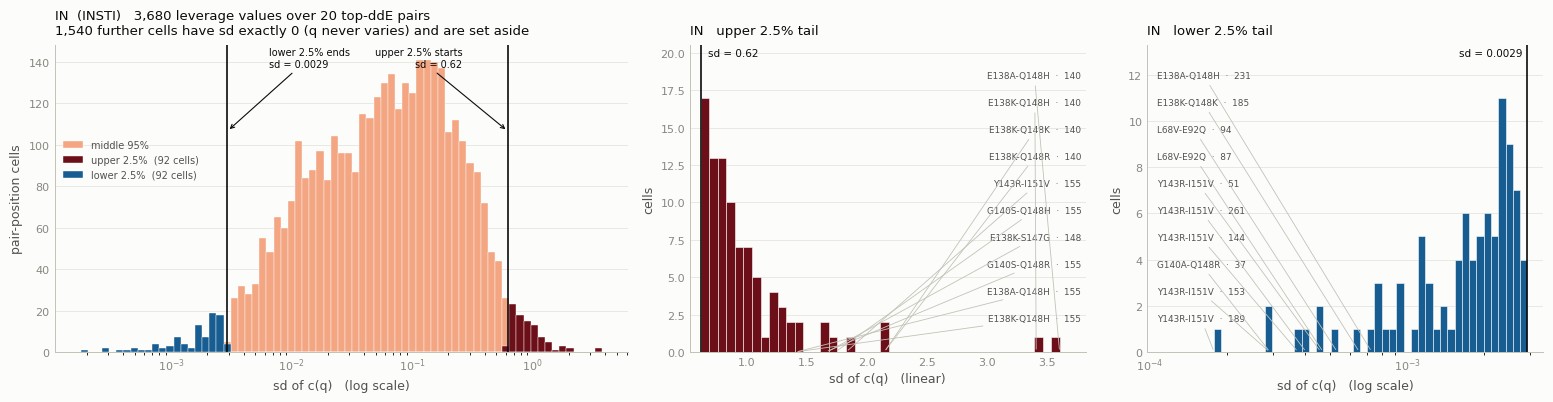

saved jterm_sd_tails_PR.png / .pdf


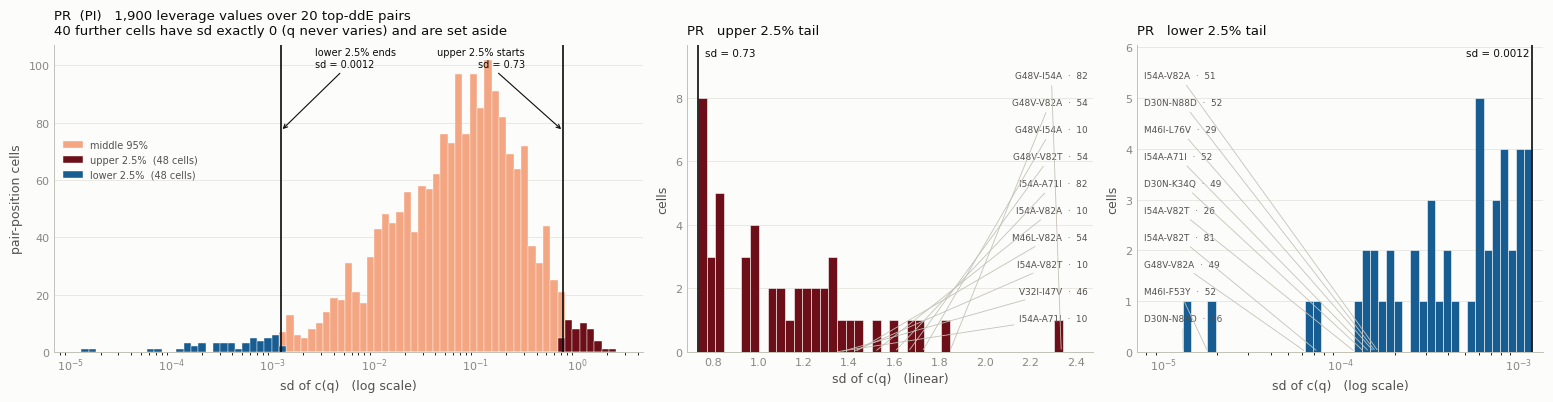

saved jterm_sd_tails_RT.png / .pdf


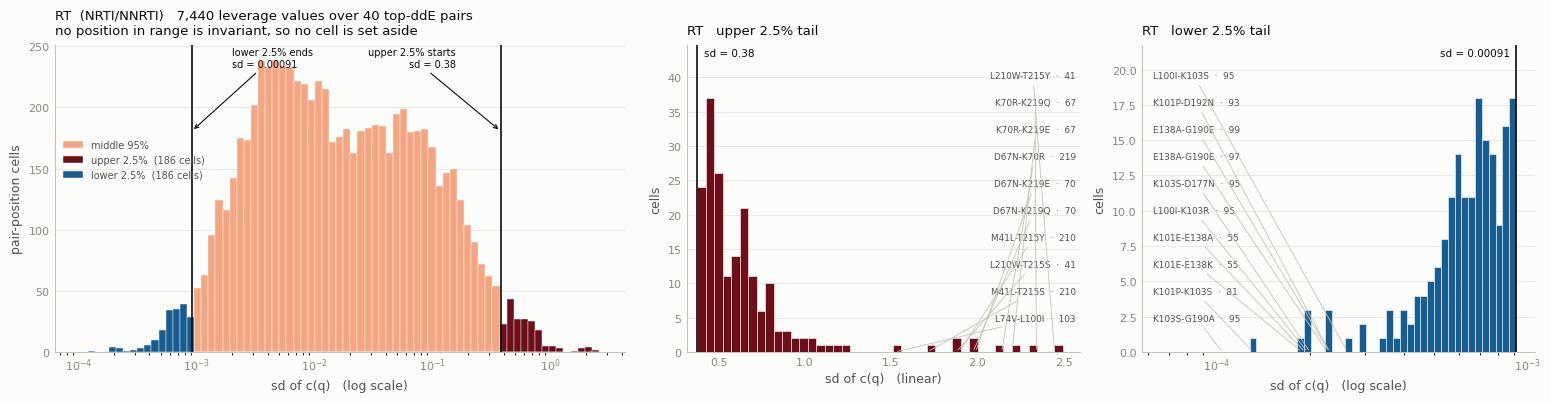

saved jterm_sd_tails_all_proteins.png / .pdf


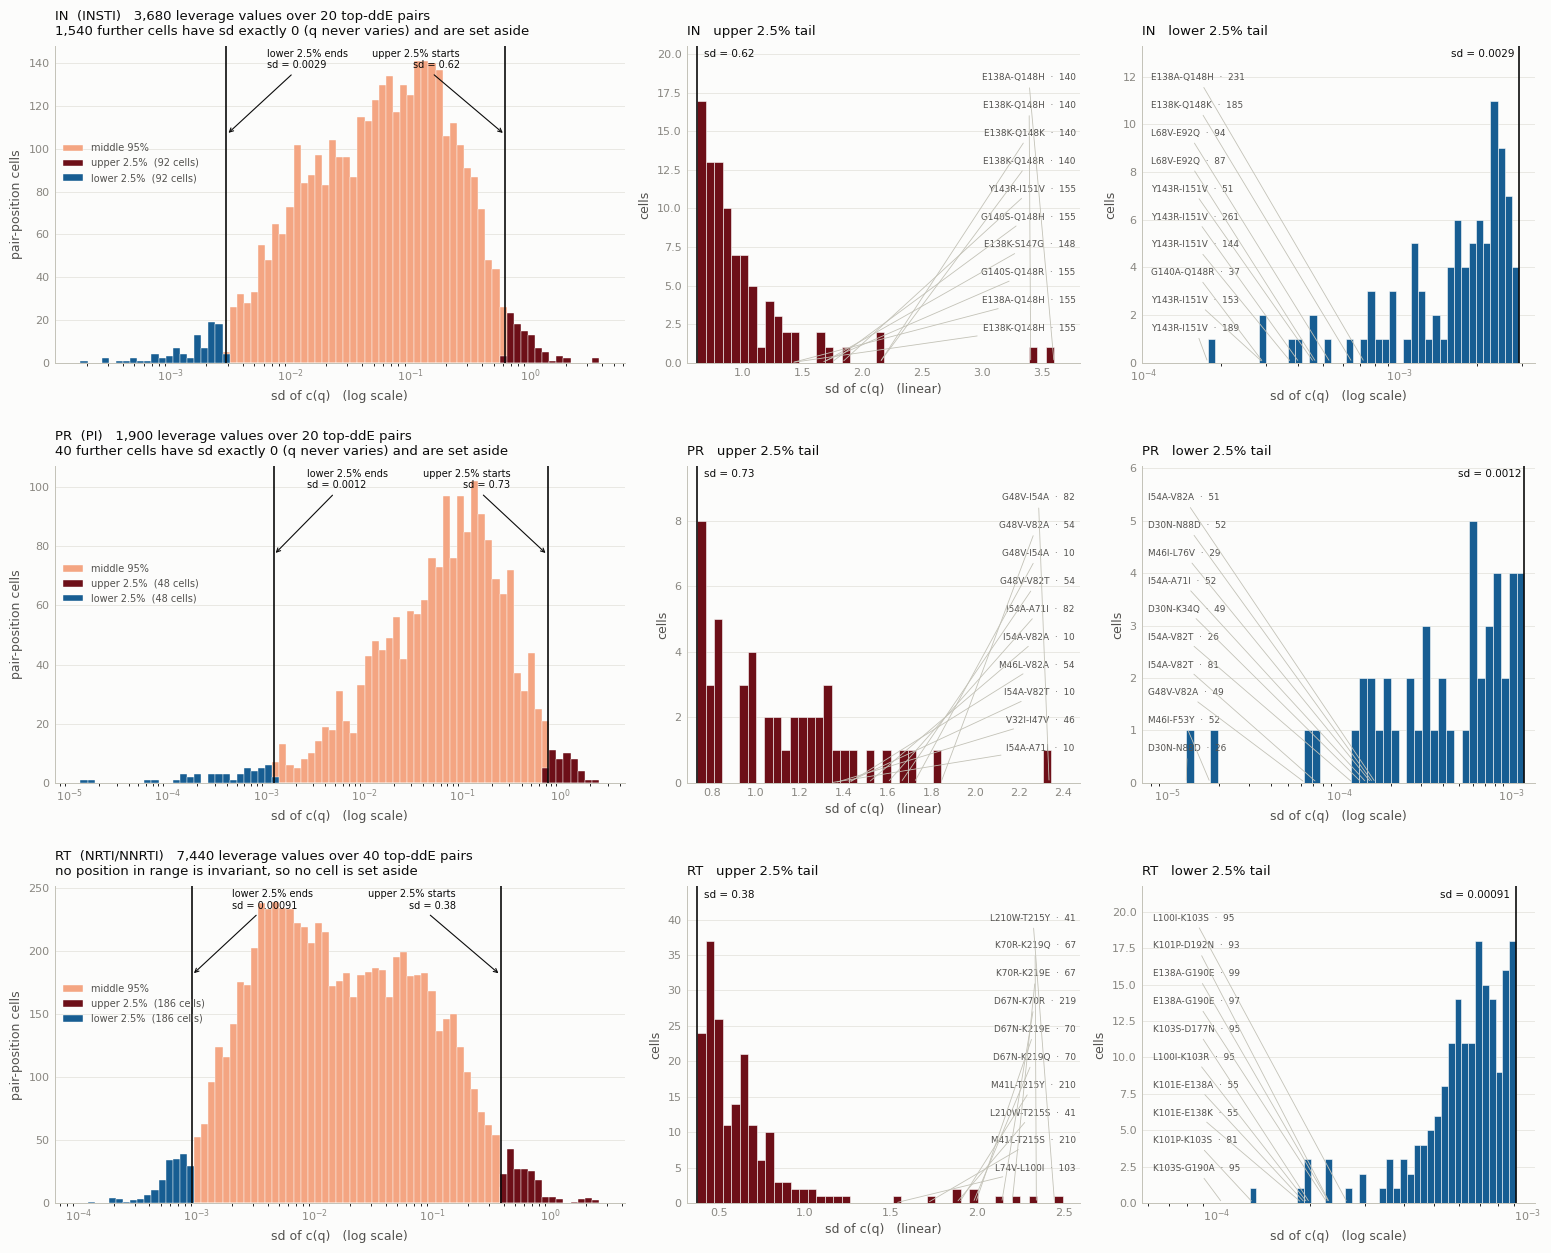

In [7]:
# =============================================================================
# THE FIGURE -- one row per protein, the same three panels the RT notebook used, now with both
# tails rather than one.
#
# LEFT: every pooled leverage value on a log axis, because they span four to six decades. Most
# background positions sit near the median and do almost nothing to their pair's dE double. The
# two shaded ends are the outer 2.5% each way and the lines are where they start.
#
# MIDDLE / RIGHT: each tail on its own, with its ten most extreme cells named -- double mutation
# and the background position q. That is the whole point of the panels: not how many positions
# are extreme, but which pair owns which position.
# =============================================================================
def ladder(ax, P, side, anchor_x):
    """Name the N_LABEL most extreme cells, stacked so the leader lines never cross.

    Both tails put the labels in a column in the empty half of the panel -- right for the upper
    tail, which decays away from its cut, left for the lower one, which decays towards it -- with
    a leader line out to each cell. Labelling in place collides with the bars near the cut,
    where several of the ten extremes sit.
    """
    top = ax.get_ylim()[1]
    for k, (i, q, v) in enumerate(extremes(P, side)):
        x = anchor_x
        ax.annotate(f'{META[P]["pair"][i]}  ·  {CFG[P]["positions"][q]}',
                    xy=(v, 0), xytext=(x, top * (0.10 + 0.088 * k)),
                    fontsize=6.4, color=INK2, ha='right' if side == 'upper' else 'left',
                    arrowprops=dict(arrowstyle='-', color=BASE, lw=0.6))


def protein_row(axD, axU, axL, P):
    pool, lo, hi = POOLED[P], LO_CUT[P], HI_CUT[P]

    # -- the whole distribution, log x ------------------------------------------------------
    bins = np.logspace(np.log10(pool.min()), np.log10(pool.max()) + 0.02, 74)
    axD.hist(pool[(pool >= lo) & (pool <= hi)], bins=bins, color=PALE, edgecolor=SURFACE,
             linewidth=0.3, label=f'middle {1 - 2 * TAIL_FRAC:.0%}', zorder=3)
    axD.hist(pool[pool > hi], bins=bins, color=DEEP, edgecolor=SURFACE, linewidth=0.3,
             label=f'upper {TAIL_FRAC:.1%}  ({int(IN_HI[P].sum()):,} cells)', zorder=4)
    axD.hist(pool[pool < lo], bins=bins, color=COOL_DEEP, edgecolor=SURFACE, linewidth=0.3,
             label=f'lower {TAIL_FRAC:.1%}  ({int(IN_LO[P].sum()):,} cells)', zorder=4)
    for cut in (lo, hi):
        axD.axvline(cut, color=INK, lw=1.2, zorder=5)
    ytop = axD.get_ylim()[1]
    axD.annotate(f'lower {TAIL_FRAC:.1%} ends\nsd = {lo:.2g}', xy=(lo, ytop * 0.72),
                 xytext=(lo * 2.2, ytop * 0.93), fontsize=7, color=INK,
                 arrowprops=dict(arrowstyle='->', color=INK, lw=0.8))
    axD.annotate(f'upper {TAIL_FRAC:.1%} starts\nsd = {hi:.2g}', xy=(hi, ytop * 0.72),
                 xytext=(hi * 0.42, ytop * 0.93), fontsize=7, color=INK, ha='right',
                 arrowprops=dict(arrowstyle='->', color=INK, lw=0.8))
    axD.set_xscale('log')
    axD.set_xlabel('sd of c(q)   (log scale)', color=INK2)
    axD.set_ylabel('pair-position cells', color=INK2)
    axD.set_title(f'{P}  ({CFG[P]["drug"]})   {pool.size:,} leverage values over '
                  f'{SD[P].shape[0]} top-ddE pairs\n'
                  + (f'{INERT[P]:,} further cells have sd exactly 0 (q never varies) and are '
                     f'set aside' if INERT[P] else 'no position in range is invariant, so no '
                     f'cell is set aside'),
                  fontsize=9.5, color=INK, loc='left', pad=8)
    bare(axD)
    axD.legend(fontsize=7, labelcolor=INK2, loc='upper left', bbox_to_anchor=(0.0, 0.72))

    # -- upper tail alone, linear x ---------------------------------------------------------
    up = pool[pool > hi]
    axU.hist(up, bins=np.linspace(hi, pool.max() * 1.02, 44), color=DEEP, edgecolor=SURFACE,
             linewidth=0.4, zorder=3)
    axU.axvline(hi, color=INK, lw=1.2, zorder=5)
    axU.set_ylim(0, axU.get_ylim()[1] * 1.15)
    axU.text(hi + (pool.max() - hi) * 0.02, axU.get_ylim()[1] * 0.99, f'sd = {hi:.2g}',
             fontsize=7.5, color=INK, va='top')
    axU.set_xlim(hi - (pool.max() - hi) * 0.03, pool.max() * 1.06)
    ladder(axU, P, 'upper', pool.max() * 1.05)
    axU.set_xlabel('sd of c(q)   (linear)', color=INK2)
    axU.set_ylabel('cells', color=INK2)
    axU.set_title(f'{P}   upper {TAIL_FRAC:.1%} tail', fontsize=9.5, color=INK, loc='left', pad=8)
    bare(axU)

    # -- lower tail alone, log x (it spans decades of its own) -------------------------------
    dn = pool[pool < lo]
    axL.hist(dn, bins=np.logspace(np.log10(dn.min()), np.log10(lo), 44), color=COOL_DEEP,
             edgecolor=SURFACE, linewidth=0.4, zorder=3)
    axL.set_xscale('log')
    axL.axvline(lo, color=INK, lw=1.2, zorder=5)
    axL.set_ylim(0, axL.get_ylim()[1] * 1.15)
    axL.set_xlim(dn.min() * 0.55, lo * 1.15)
    axL.text(lo * 0.96, axL.get_ylim()[1] * 0.99, f'sd = {lo:.2g}', fontsize=7.5, color=INK,
             va='top', ha='right')
    ladder(axL, P, 'lower', dn.min() * 0.6)
    axL.set_xlabel('sd of c(q)   (log scale)', color=INK2)
    axL.set_ylabel('cells', color=INK2)
    axL.set_title(f'{P}   lower {TAIL_FRAC:.1%} tail', fontsize=9.5, color=INK, loc='left', pad=8)
    bare(axL)


RATIOS = {'width_ratios': [1.45, 1, 1]}

# one figure per protein
for P in PROTEINS:
    fig, axes = plt.subplots(1, 3, figsize=(15.6, 4.1), gridspec_kw=RATIOS)
    protein_row(*axes, P)
    fig.tight_layout()
    fig.savefig(f'jterm_sd_tails_{P}.png', dpi=400, bbox_inches='tight', pad_inches=0.03,
                facecolor=SURFACE)
    fig.savefig(f'jterm_sd_tails_{P}.pdf', bbox_inches='tight', pad_inches=0.03, facecolor=SURFACE)
    print(f'saved jterm_sd_tails_{P}.png / .pdf')
    plt.show()

# and the three stacked, for the manuscript
fig, axes = plt.subplots(3, 3, figsize=(15.6, 12.6), gridspec_kw=RATIOS)
for row, P in zip(axes, PROTEINS):
    protein_row(*row, P)
fig.tight_layout(h_pad=2.2)
fig.savefig('jterm_sd_tails_all_proteins.png', dpi=400, bbox_inches='tight', pad_inches=0.03,
            facecolor=SURFACE)
fig.savefig('jterm_sd_tails_all_proteins.pdf', bbox_inches='tight', pad_inches=0.03,
            facecolor=SURFACE)
print('saved jterm_sd_tails_all_proteins.png / .pdf')
plt.show()

In [8]:
# =============================================================================
# The same two selections as text, and everything the figures did not have room for.
# =============================================================================
pd.set_option('display.max_columns', None, 'display.width', 220)

LABELLED = pd.concat(
    [pd.DataFrame([{'protein': P, 'tail': side, 'rank': k + 1,
                    'pair': META[P]['pair'][i], 'q': CFG[P]['positions'][q],
                    'sd of c(q)': v, 'ddE': META[P]['dde'][i],
                    'carriers': META[P]['carriers'][i],
                    'dE double range (95-5%)': META[P]['dE double range (95-5%)'][i]}
                   for k, (i, q, v) in enumerate(extremes(P, side)[::-1])])
     for P in PROTEINS for side in ('upper', 'lower')], ignore_index=True)

# which background positions turn up in the upper tail for the most different pairs
HOTSPOTS = (CELLS[CELLS['tail'] == 'upper']
            .groupby(['protein', 'q'])
            .agg(**{'pairs in upper tail': ('pair', 'size'),
                    'largest sd of c(q)': ('sd of c(q)', 'max'),
                    'median sd of c(q)': ('sd of c(q)', 'median')})
            .reset_index()
            .sort_values(['protein', 'pairs in upper tail'], ascending=[True, False])
            .groupby('protein').head(10).reset_index(drop=True))

# per-pair summary: how much of each pair's profile lands in each tail
BY_PAIR = pd.concat(
    [pd.DataFrame({'protein': P, 'pair': META[P]['pair'],
                   'ddE': META[P]['dde'], 'carriers': META[P]['carriers'],
                   'dE double range (95-5%)': META[P]['dE double range (95-5%)'],
                   'positions in upper tail': IN_HI[P].sum(axis=1),
                   'positions in lower tail': IN_LO[P].sum(axis=1),
                   'positions with sd = 0': (TESTABLE[P] & (SD[P] == 0)).sum(axis=1),
                   'largest sd of c(q)': np.where(TESTABLE[P], SD[P], 0).max(axis=1)})
     .sort_values('positions in upper tail', ascending=False)
     for P in PROTEINS], ignore_index=True)

CUTS.to_csv('jterm_sd_tail_cuts_all_proteins.csv', index=False)
LABELLED.to_csv('jterm_sd_tail_labelled_cells_all_proteins.csv', index=False)
CELLS.to_csv('jterm_sd_tail_cells_all_proteins.csv', index=False)
BY_PAIR.to_csv('jterm_sd_tail_by_pair_all_proteins.csv', index=False)
HOTSPOTS.to_csv('jterm_sd_upper_tail_hotspots_all_proteins.csv', index=False)
print('saved jterm_sd_tail_cuts_all_proteins.csv, jterm_sd_tail_labelled_cells_all_proteins.csv,\n'
      '      jterm_sd_tail_cells_all_proteins.csv, jterm_sd_tail_by_pair_all_proteins.csv,\n'
      f'      jterm_sd_upper_tail_hotspots_all_proteins.csv   ({len(CELLS):,} tail cells)')
display(LABELLED.round(4))
display(HOTSPOTS.round(3))
BY_PAIR.round(3)

saved jterm_sd_tail_cuts_all_proteins.csv, jterm_sd_tail_labelled_cells_all_proteins.csv,
      jterm_sd_tail_cells_all_proteins.csv, jterm_sd_tail_by_pair_all_proteins.csv,
      jterm_sd_upper_tail_hotspots_all_proteins.csv   (652 tail cells)


,protein,tail,rank,pair,q,sd of c(q),ddE,carriers,dE double range (95-5%)
0,IN,upper,1,E138A-Q148H,140,3.6018,2.13,15,16.7426
1,IN,upper,2,E138K-Q148H,140,3.4069,2.36,10,15.8005
2,IN,upper,3,E138K-Q148K,140,2.1448,4.90,4,12.4851
3,IN,upper,4,E138K-Q148R,140,2.1427,3.53,21,13.5697
4,IN,upper,5,Y143R-I151V,155,1.8271,NaN,-1,10.6233
5,IN,upper,6,G140S-Q148H,155,1.7375,8.51,221,10.2645
6,IN,upper,7,E138K-S147G,148,1.6693,2.66,13,9.4975
7,IN,upper,8,G140S-Q148R,155,1.6560,5.20,19,11.4867
8,IN,upper,9,E138A-Q148H,155,1.4111,2.13,15,16.7426
9,IN,upper,10,E138K-Q148H,155,1.4024,2.36,10,15.8005


,protein,q,pairs in upper tail,largest sd of c(q),median sd of c(q)
0,IN,155,15,1.827,1.228
1,IN,140,11,3.602,1.039
2,IN,119,7,1.357,0.830
3,IN,148,7,1.669,0.993
4,IN,97,5,0.848,0.775
5,IN,124,5,1.005,0.793
6,IN,138,5,1.148,0.986
7,IN,151,5,0.960,0.739
8,IN,143,4,0.984,0.790
9,IN,17,3,0.837,0.811


,protein,pair,ddE,carriers,dE double range (95-5%),positions in upper tail,positions in lower tail,positions with sd = 0,largest sd of c(q)
0,IN,E92Q-K215R,2.25,1,9.595,7,8,77,0.904
1,IN,G140C-Q148R,2.99,6,11.229,7,1,77,1.220
2,IN,G140A-Q148R,4.91,10,11.608,6,1,77,1.380
3,IN,T97A-Y143R,2.84,39,11.771,6,0,77,1.228
4,IN,Y143S-S230R,3.70,4,10.371,6,1,77,0.960
...,...,...,...,...,...,...,...,...,...
75,RT,F116Y-Q151R,1.99,0,5.334,2,5,0,0.523
76,RT,K101E-G190S,3.30,226,6.432,2,5,0,1.212
77,RT,K101E-E138A,1.27,110,5.890,2,10,0,1.119
78,RT,V108I-V189I,1.17,217,5.370,2,5,0,0.549
